In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
fashion_mnist=keras.datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']


In [2]:
Tr_Im=train_images.shape
Tr_label=len(train_labels)
Labels=train_labels
print('Тренировочный массив изображений', Tr_Im)
print('Тренировочный массив меток', Tr_label)
print('Метки изображений',Labels)

Test_Im=test_images.shape
Test_label=len(test_labels)
print('Тестовый массив изображений',Test_Im)
print('Тестовый массив меток',Test_label)

Тренировочный массив изображений (60000, 28, 28)
Тренировочный массив меток 60000
Метки изображений [9 0 0 ... 3 0 5]
Тестовый массив изображений (10000, 28, 28)
Тестовый массив меток 10000


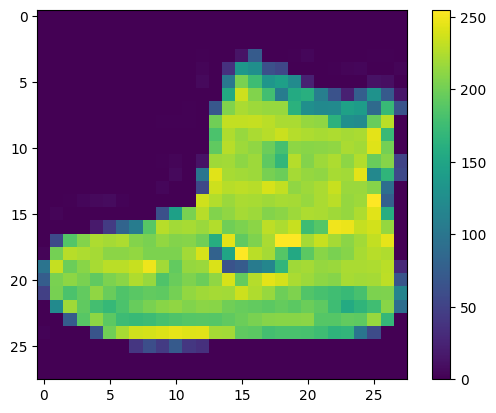

In [3]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [4]:
train_images=train_images/255.0
test_images=test_images/255.0

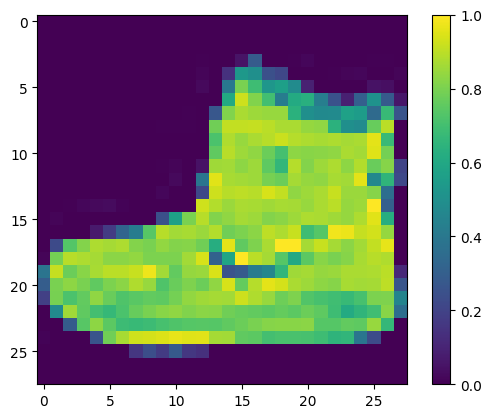

In [5]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

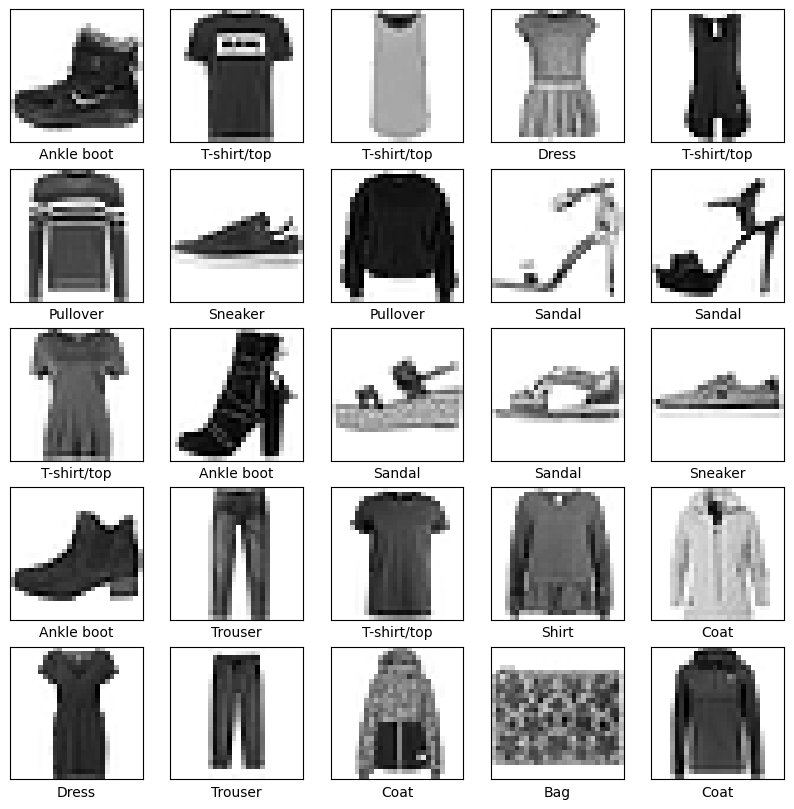

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i],cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [7]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

C:\Users\Intel\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
model.fit(train_images,train_labels,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7825 - loss: 0.6253
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8661 - loss: 0.3760
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8758 - loss: 0.3429
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8882 - loss: 0.3090
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8929 - loss: 0.2926
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8973 - loss: 0.2795
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9006 - loss: 0.2659
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9061 - loss: 0.2560
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9106 - loss: 0.2418
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9137 - loss: 0.2288


In [10]:
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=2)
print('\nТочность на проверочных данных:',test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8776 - loss: 0.3664

Точность на проверочных данных: 0.8776000142097473


In [11]:
predictions=model.predict(test_images)
ver1=predictions[0]
im1=np.argmax(predictions[0])
lab1=test_labels[0]
print('Вероятность предсказания для первого рисунка',ver1)
print('Первое изображение (после обучения)',im1)
print('Метка первого изображения',lab1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Вероятность предсказания для первого рисунка [1.4101753e-09 7.8734006e-09 5.7327082e-08 4.3181189e-10 6.6764008e-09
 5.3379056e-03 6.4499557e-07 6.7518063e-02 2.8089455e-06 9.2714053e-01]
Первое изображение (после обучения) 9
Метка первого изображения 9


In [12]:
def plot_image(i,predictions_array,true_label,img):
    predictions_array,true_label,img=predictions_array[i],true_label[i],img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img,cmap=plt.cm.binary)

    predicted_label=np.argmax(predictions_array)
    if predicted_label==true_label:
        color='blue'
    else:
        color='red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],100*np.max(predictions_array),class_names[true_label]),color=color)

def plot_value_array(i,predictions_array,true_label):
    predictions_array,true_label=predictions_array[i],true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot=plt.bar(range(10),predictions_array,color="#777777")
    plt.ylim([0,1])
    predicted_label=np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

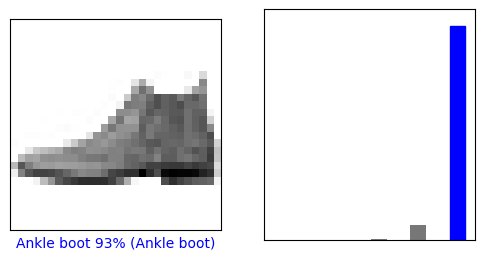

In [13]:
i=0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i,predictions,test_labels,test_images)
plt.subplot(1,2,2)
plot_value_array(i,predictions,test_labels)
plt.show()

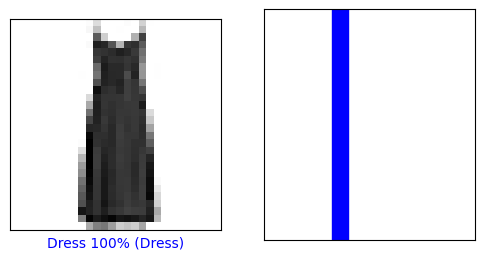

In [14]:
i=13
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i,predictions,test_labels,test_images)
plt.subplot(1,2,2)
plot_value_array(i,predictions,test_labels)
plt.show()

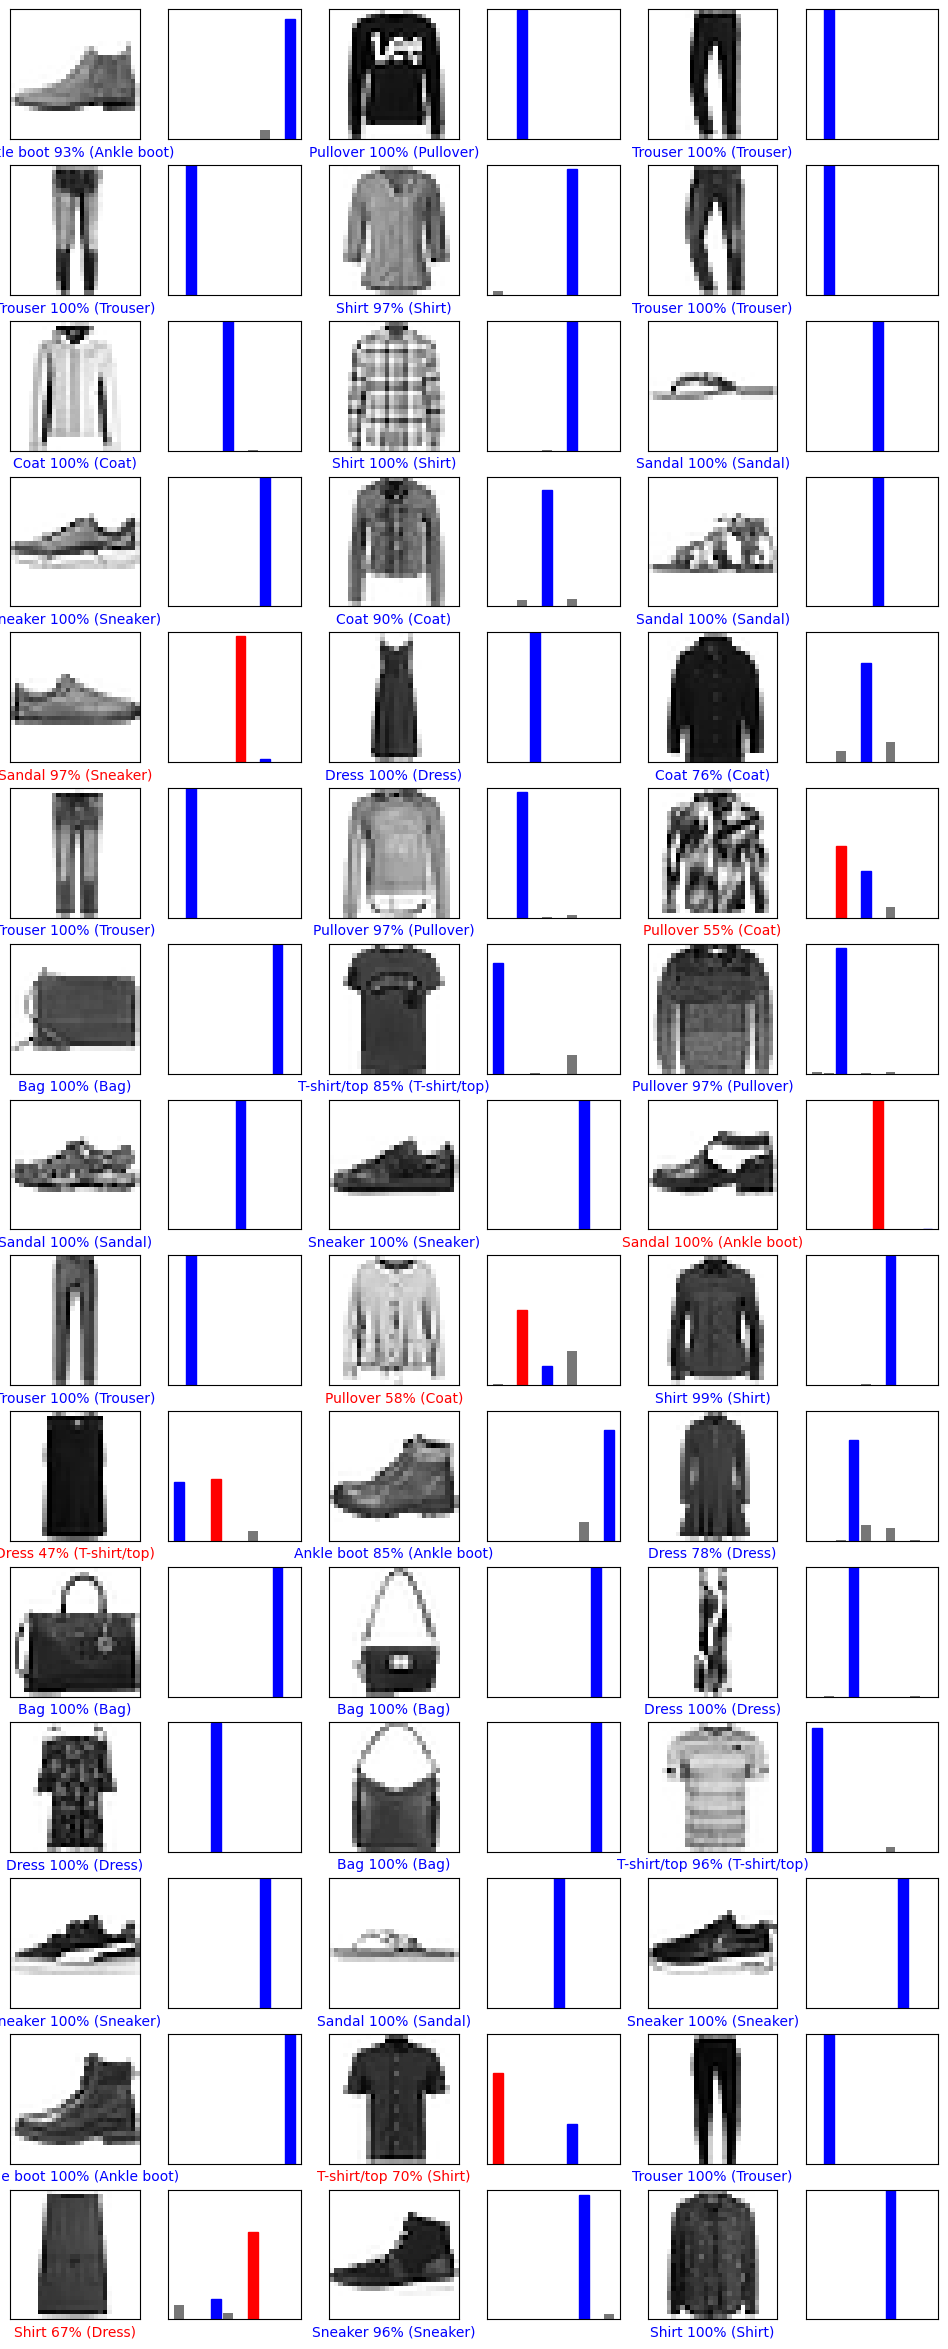

In [15]:
num_rows=15
num_cols=3
num_images=num_rows*num_cols
plt.figure(figsize=(2*2*num_cols,2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows,2*num_cols,2*i+1)
    plot_image(i,predictions,test_labels,test_images)
    plt.subplot(num_rows,2*num_cols,2*i+2)
    plot_value_array(i,predictions,test_labels)
plt.show()

In [16]:
img = test_images[0] 
print ( img. shape) 
# Добавляем изображение в пакет данных, состоящий только из одного элемента 
img = (np.expand_dims(img, 0)) 
print(img.shape) 
predictions_single = model.predict(img) 
print('Пpoвepкa на изображении из тестового набора данных') 
print(predictions_single) 
met = np.argmax(predictions_single[0]) 
print ( 'Метка класса одежды', met)

(28, 28)
(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Пpoвepкa на изображении из тестового набора данных
[[1.4101753e-09 7.8733864e-09 5.7327082e-08 4.3181353e-10 6.6763879e-09
  5.3379112e-03 6.4499500e-07 6.7518078e-02 2.8089428e-06 9.2714053e-01]]
Метка класса одежды 9


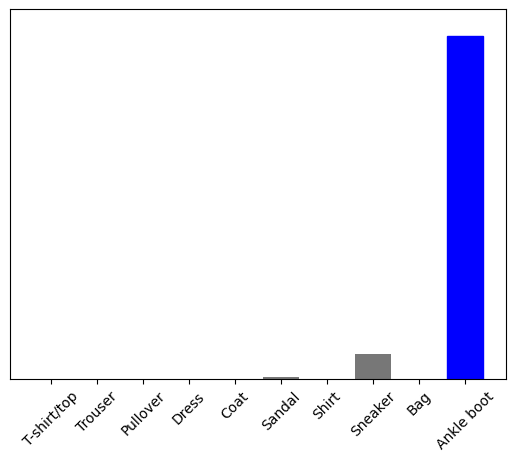

In [17]:
plot_value_array(0, predictions_single, test_labels) 
plt.xticks(range(10), class_names, rotation=45) 
plt.show()